In [83]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.naive_bayes import GaussianNB 
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, adjusted_rand_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap


In [2]:
dataset_path = r"D:\BTECH CSE AMITY\AIML\SEM 3\plant_disease_project\dataset"

In [3]:
def extract_features(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
     
    hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [4]:
features = []
labels = []

for category in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, category)
    if not os.path.isdir(folder):
        continue
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        try:
            feat = extract_features(file_path)
            features.append(feat)
            labels.append(category)
        except Exception as e:
            print("Error reading:", file, e)


features = np.array(features)
labels = np.array(labels)

print("Features shape:", features.shape)
print("Labels:", np.unique(labels))


Features shape: (11254, 512)
Labels: ['diseased' 'healthy']


In [5]:
le = LabelEncoder()
y = le.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 9003
Testing samples: 2251


In [6]:
x = X_train

In [7]:
X= X_test

In [8]:
X_train

array([[0.00208513, 0.00278018, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.0222312 , ..., 0.        , 0.        ,
        0.        ],
       [0.00178628, 0.00102073, 0.00280702, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.00087083, 0.00609581, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.00110163, 0.00110163, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00509738, ..., 0.        , 0.        ,
        0.        ]], shape=(9003, 512), dtype=float32)

In [9]:
X_test

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00273972, 0.00356164, 0.00273972, ..., 0.        , 0.        ,
        0.        ],
       [0.00159657, 0.00219528, 0.00219528, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00032926, 0.00098778, 0.0016463 , ..., 0.        , 0.        ,
        0.        ],
       [0.0001938 , 0.0003876 , 0.00174422, ..., 0.        , 0.        ,
        0.        ],
       [0.00033606, 0.00016803, 0.0016803 , ..., 0.        , 0.        ,
        0.        ]], shape=(2251, 512), dtype=float32)

# Support Vector Machine (SVM)

In [10]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)

SVC(C=1)

In [11]:
svm.predict(X_test)

array([0, 0, 0, ..., 1, 1, 0], shape=(2251,))

In [12]:
svm.score(X_test,y_test)

0.9733451799200356

In [13]:
model = SVC(probability=True)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Precision:", precision_score(y_test, y_pred_svm))
print("SVM Recall:", recall_score(y_test, y_pred_svm))
print("SVM F-1 score:", f1_score(y_test, y_pred_svm))

SVM Accuracy: 0.9733451799200356
SVM Precision: 0.9464831804281345
SVM Recall: 0.9611801242236024
SVM F-1 score: 0.9537750385208013


# Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
importances = rf.feature_importances_

In [16]:
rf.predict(X_test)

array([0, 0, 0, ..., 1, 1, 0], shape=(2251,))

In [17]:
rf.score(X_test,y_test)

0.988005330964016

In [18]:
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest F-1 score:", f1_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.988005330964016
Random Forest Precision: 0.9797822706065319
Random Forest Recall: 0.9782608695652174
Random Forest F-1 score: 0.9790209790209791


# LogisticRegression


In [19]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [20]:
lr.predict(X_test)

array([0, 0, 0, ..., 1, 1, 0], shape=(2251,))

In [21]:
lr.score(X_test,y_test)

0.9218125277654375

In [22]:
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Precision:", precision_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print("Logistic Regression F-1 score:", f1_score(y_test, y_pred_lr))

Logistic Regression Accuracy : 0.9218125277654375
Logistic Regression Precision: 0.8588957055214724
Logistic Regression Recall: 0.8695652173913043
Logistic Regression F-1 score: 0.8641975308641975


# K-Nearest Neighbors

In [23]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [24]:
knn.predict(X_test)

array([0, 0, 0, ..., 1, 1, 0], shape=(2251,))

In [25]:
knn.score(X_test,y_test)

0.9484673478454021

In [26]:
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))
print("KNN F-1 score:", f1_score(y_test, y_pred_knn))

KNN Accuracy: 0.9484673478454021
KNN Precision: 0.8952095808383234
KNN Recall: 0.9285714285714286
KNN F-1 score: 0.9115853658536586


# Simple Linear Regression

In [27]:
li_r = LinearRegression()
li_r.fit(X_train,y_train)

LinearRegression()

In [28]:
li_r.coef_ 

array([-3.1655231e-01,  1.3988301e-01, -4.3235829e-01, -1.8685062e-01,
       -5.6622073e-02, -3.6908326e-01,  2.8411427e-01, -3.2266885e-01,
        2.7792013e-01, -9.2967862e-01, -1.0887370e+00, -2.0538814e-02,
       -3.4719855e-02, -3.3950174e-01,  4.3137825e-01, -2.5508995e+00,
        9.5276248e-01,  1.9063088e+00, -2.1608725e+00, -4.0421882e+00,
        1.3425158e-01, -8.8837516e-01,  3.6924595e-01, -7.2045237e-01,
       -8.8155556e-01,  6.8917280e-01,  4.5274253e+00, -1.8083353e-01,
       -1.7775178e+00,  1.4199302e+00,  1.5945977e-01,  6.6055053e-01,
       -6.4198714e-01, -1.6041946e+00, -1.7015651e+00,  1.4061248e+00,
       -1.7731681e-01, -6.4267951e-01,  2.3803507e-01, -1.9117329e-01,
       -9.5031446e-01,  2.9043812e-01,  4.8904574e-01, -2.7141094e+00,
        1.6017553e+00,  1.3123180e-01, -2.0677140e-01,  1.7967651e+00,
       -5.0994354e-01,  5.3379905e-01, -2.4385891e+00,  3.5322651e-02,
       -4.0553862e-01,  4.3057371e-02, -1.2124443e+00,  8.4710658e-01,
      

In [29]:
li_r.intercept_

np.float32(0.31579512)

In [32]:
y_pred  =li_r.predict(X_test)
y_pred_li_r = np.round(y_pred).astype(int)
y_pred
y_pred_li_r

array([0, 0, 0, ..., 1, 1, 0], shape=(2251,))

In [33]:
x_pred = li_r.predict(X_train)
x_pred

array([ 0.15083398, -0.1296385 ,  0.02985841, ...,  0.12739103,
        0.84700036,  0.06072488], shape=(9003,), dtype=float32)

In [34]:
li_r.score(X_test,y_test)

0.5774985551834106

In [35]:
li_r.score(X_train,y_train)

0.600831151008606

Linear model can only handle regression not classification so we can use logistic regression instead of linear regression as linear regression predict continuous data output whereas logistic regression predict discrete class labels

# PCA

In [36]:
pca = PCA(0.97)
X_pca = pca.fit_transform(X)
X_pca.shape

(2251, 55)

In [37]:
pca.explained_variance_ratio_

array([0.16214468, 0.11172432, 0.09728745, 0.05920371, 0.0524282 ,
       0.04507065, 0.04238498, 0.03513901, 0.02826109, 0.02565371,
       0.02360374, 0.02198828, 0.02057499, 0.01766708, 0.01722256,
       0.01560159, 0.01292289, 0.01237568, 0.01147904, 0.01013833,
       0.01010056, 0.00912363, 0.00880211, 0.00840849, 0.008053  ,
       0.00755802, 0.00743015, 0.00634154, 0.00595761, 0.00519178,
       0.00479954, 0.00460593, 0.00450708, 0.00420868, 0.0040856 ,
       0.00402106, 0.00392012, 0.00366323, 0.00334238, 0.00301699,
       0.00289514, 0.00269777, 0.0026034 , 0.00232484, 0.00229545,
       0.00219894, 0.00212972, 0.00199937, 0.00183642, 0.00180593,
       0.00175913, 0.00156421, 0.00148837, 0.00129337, 0.00127689],
      dtype=float32)

In [38]:
pca.n_components

0.97

In [39]:
pca.n_components_

np.int64(55)

In [40]:
X_pca

array([[-0.00572909,  0.19126195, -0.29039142, ..., -0.03347546,
         0.03446825,  0.02602737],
       [-0.1891534 ,  0.27086937, -0.38192853, ...,  0.0077794 ,
        -0.03605153, -0.00416949],
       [ 0.18452905,  0.24692023, -0.18663171, ...,  0.0128368 ,
        -0.01405766,  0.01070087],
       ...,
       [-0.25318483,  0.5355324 ,  0.3575435 , ...,  0.01644055,
         0.00424363,  0.01001748],
       [ 0.5945697 , -0.15942815,  0.22618297, ...,  0.00670899,
        -0.01163941, -0.00522588],
       [-0.3581536 ,  0.4613066 ,  0.11806817, ..., -0.00549863,
         0.01191485, -0.01336755]], shape=(2251, 55), dtype=float32)

In [41]:
X_train_pca,X_test_pca,y_train,y_test = train_test_split(X_pca , y , test_size = 0.2 , random_state = 0)

ValueError: Found input variables with inconsistent numbers of samples: [2251, 11254]

In [42]:
lr_pca = LogisticRegression(max_iter = 1000)
lr_pca.fit (X_train_pca , y_train)

NameError: name 'X_train_pca' is not defined

In [43]:
lr_pca.score(X_test_pca, y_test)

NameError: name 'X_test_pca' is not defined

Healty images ka dataset badhane se error hatt jaega

# Multiple Linear Regression

In [44]:
reg= linear_model.LinearRegression()
reg.fit(X_train,y_train) 

LinearRegression()

In [45]:
reg.coef_

array([-3.1655231e-01,  1.3988301e-01, -4.3235829e-01, -1.8685062e-01,
       -5.6622073e-02, -3.6908326e-01,  2.8411427e-01, -3.2266885e-01,
        2.7792013e-01, -9.2967862e-01, -1.0887370e+00, -2.0538814e-02,
       -3.4719855e-02, -3.3950174e-01,  4.3137825e-01, -2.5508995e+00,
        9.5276248e-01,  1.9063088e+00, -2.1608725e+00, -4.0421882e+00,
        1.3425158e-01, -8.8837516e-01,  3.6924595e-01, -7.2045237e-01,
       -8.8155556e-01,  6.8917280e-01,  4.5274253e+00, -1.8083353e-01,
       -1.7775178e+00,  1.4199302e+00,  1.5945977e-01,  6.6055053e-01,
       -6.4198714e-01, -1.6041946e+00, -1.7015651e+00,  1.4061248e+00,
       -1.7731681e-01, -6.4267951e-01,  2.3803507e-01, -1.9117329e-01,
       -9.5031446e-01,  2.9043812e-01,  4.8904574e-01, -2.7141094e+00,
        1.6017553e+00,  1.3123180e-01, -2.0677140e-01,  1.7967651e+00,
       -5.0994354e-01,  5.3379905e-01, -2.4385891e+00,  3.5322651e-02,
       -4.0553862e-01,  4.3057371e-02, -1.2124443e+00,  8.4710658e-01,
      

In [46]:
reg.intercept_

np.float32(0.31579512)

In [47]:
reg.score(X_test,y_test)

0.5774985551834106

# Naive Bayes Classifier

In [48]:
gnbs = GaussianNB() 
gnbs.fit(X_train,y_train)

GaussianNB()

In [49]:
gnbs.score(X_test,y_test)

0.8956019546868058

In [50]:
y_pred_gnbs = gnbs.predict(X_test)
print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnbs))
print("GaussianNB Precision:", precision_score(y_test, y_pred_gnbs))
print("GaussianNB Recall:", recall_score(y_test, y_pred_gnbs))
print("GaussianNB F-1 score:", f1_score(y_test, y_pred_gnbs))

GaussianNB Accuracy: 0.8956019546868058
GaussianNB Precision: 0.7478787878787879
GaussianNB Recall: 0.9580745341614907
GaussianNB F-1 score: 0.8400272294077604


In [51]:
mnbs = MultinomialNB()
mnbs.fit(X_train,y_train)

MultinomialNB()

In [52]:
mnbs.score(X_test,y_test)

0.8725011106175034

In [53]:
y_pred_mnbs = mnbs.predict(X_test)
print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred_mnbs))
print("MultinomialNB Precision:", precision_score(y_test, y_pred_mnbs))
print("MultinomialNB Recall:", recall_score(y_test, y_pred_mnbs))
print("MultinomialNB F-1 score:", f1_score(y_test, y_pred_mnbs))

MultinomialNB Accuracy: 0.8725011106175034
MultinomialNB Precision: 0.9180327868852459
MultinomialNB Recall: 0.6086956521739131
MultinomialNB F-1 score: 0.7320261437908496


In [54]:
bnbs = BernoulliNB()
bnbs.fit(X_train,y_train)

BernoulliNB()

In [55]:
bnbs.score(X_test,y_test)

0.8587294535761884

In [56]:
y_pred_bnbs = bnbs.predict(X_test)
print("BernoulliNB Accuracy:", accuracy_score(y_test, y_pred_bnbs))
print("BernoulliNB Precision:", precision_score(y_test, y_pred_bnbs))
print("BernoulliNB Recall:", recall_score(y_test, y_pred_bnbs))
print("BernoulliNB F-1 score:", f1_score(y_test, y_pred_bnbs))

BernoulliNB Accuracy: 0.8587294535761884
BernoulliNB Precision: 0.7047738693467337
BernoulliNB Recall: 0.8711180124223602
BernoulliNB F-1 score: 0.7791666666666667


# K-Best Chi2

In [57]:
kb = SelectKBest(score_func=chi2,k=10)
kb

SelectKBest(score_func=<function chi2 at 0x0000021D45F45580>)

In [58]:
kb = kb.fit(X,y)
kb 

ValueError: Found input variables with inconsistent numbers of samples: [2251, 11254]

# K-Means

In [59]:
km=KMeans(n_clusters=3)
km.fit(X_train, y_train)

KMeans(n_clusters=3)

In [60]:
km.predict(X_test)

array([2, 2, 1, ..., 2, 1, 2], shape=(2251,), dtype=int32)

In [61]:
km.score(X_test,y_test)

-1345.142822265625

In [62]:
km.score(X_train,y_train)

-5453.970703125

In [63]:
y_pred_km = km.predict(X_test)
print("KMeans Accuracy:", accuracy_score(y_test, y_pred_km))

KMeans Accuracy: 0.3931585961794758


# Min Max Scaler

In [64]:
scaler=MinMaxScaler()
scaler.fit(X_train, y_train)

MinMaxScaler()

# Feature Scaling

In [65]:
st_x = StandardScaler()
st_x.fit(X_train, y_train)

StandardScaler()

In [66]:
st_x_train=st_x.fit_transform(X_train)

In [67]:
st_x_test=st_x.fit_transform(X_test)

In [68]:
st_x_train

array([[-0.12564857, -0.06129903, -0.33163887, ...,  0.        ,
         0.        ,  0.        ],
       [-0.1441446 , -0.3090343 ,  0.18112127, ...,  0.        ,
         0.        ,  0.        ],
       [-0.12829949, -0.21807899, -0.2668953 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.1441446 , -0.23143661, -0.19103971, ...,  0.        ,
         0.        ,  0.        ],
       [-0.1441446 , -0.21087088, -0.30622998, ...,  0.        ,
         0.        ,  0.        ],
       [-0.1441446 , -0.3090343 , -0.21406846, ...,  0.        ,
         0.        ,  0.        ]], shape=(9003, 512), dtype=float32)

In [69]:
st_x_test

array([[-0.13992292, -0.26430196, -0.3307046 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.11374857, -0.04221184, -0.2722079 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.12466989, -0.12741292, -0.28383255, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.1367773 , -0.20270795, -0.295554  , ...,  0.        ,
         0.        ,  0.        ],
       [-0.13807139, -0.24013244, -0.29346323, ...,  0.        ,
         0.        ,  0.        ],
       [-0.1367123 , -0.2538242 , -0.29482788, ...,  0.        ,
         0.        ,  0.        ]], shape=(2251, 512), dtype=float32)

In [70]:
models = ['SVM', 'Random Forest', 'LogisticRegression', 'KNN', 'GaussianNB', 'MultinomialNB', 'BernoulliNB', 'KMeans']
accuracies = [
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_gnbs),
    accuracy_score(y_test, y_pred_mnbs),
    accuracy_score(y_test, y_pred_bnbs),
    accuracy_score(y_test, y_pred_km)
]


## Bar Graph of all Algo


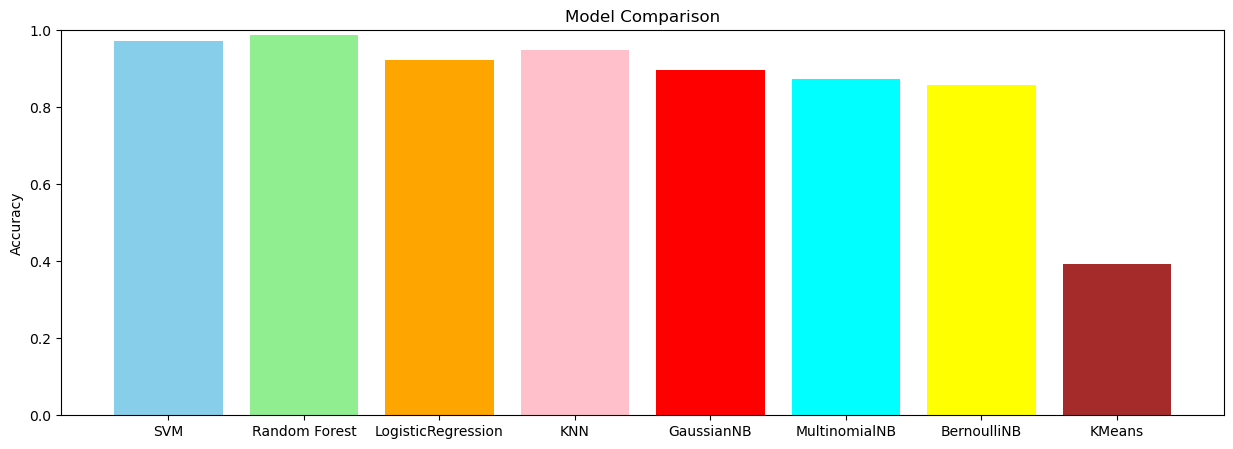

In [71]:
plt.figure(figsize=(15, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'orange','pink','red','cyan','yellow','brown'])
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  
plt.show()

## Line Plot of all Algo

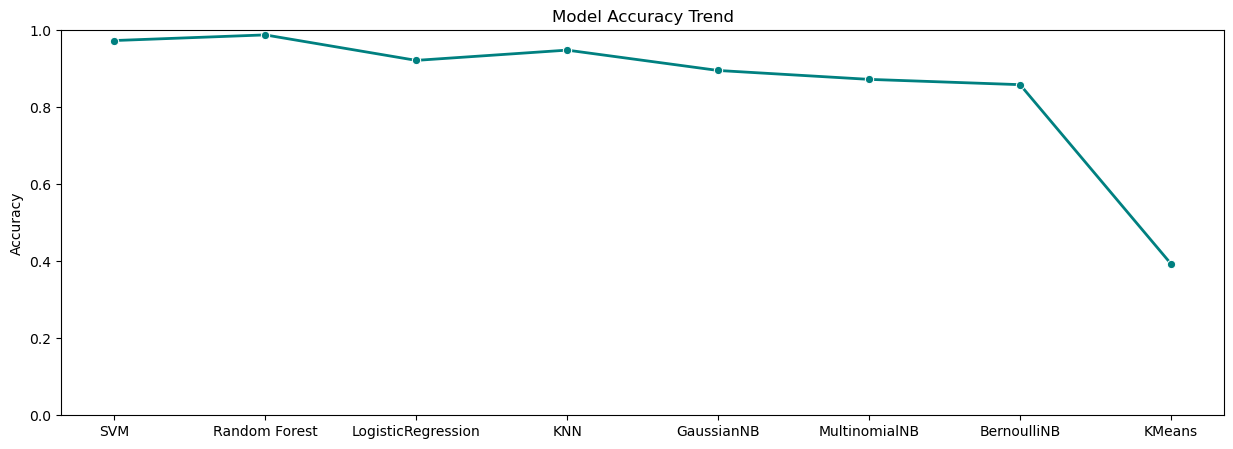

In [72]:
plt.figure(figsize=(15,5))
sns.lineplot(x=models, y=accuracies, marker='o', linewidth=2, color='teal')
plt.ylim(0,1)
plt.title('Model Accuracy Trend')
plt.ylabel('Accuracy')
plt.show()

## Scatter Plot Of All Algo

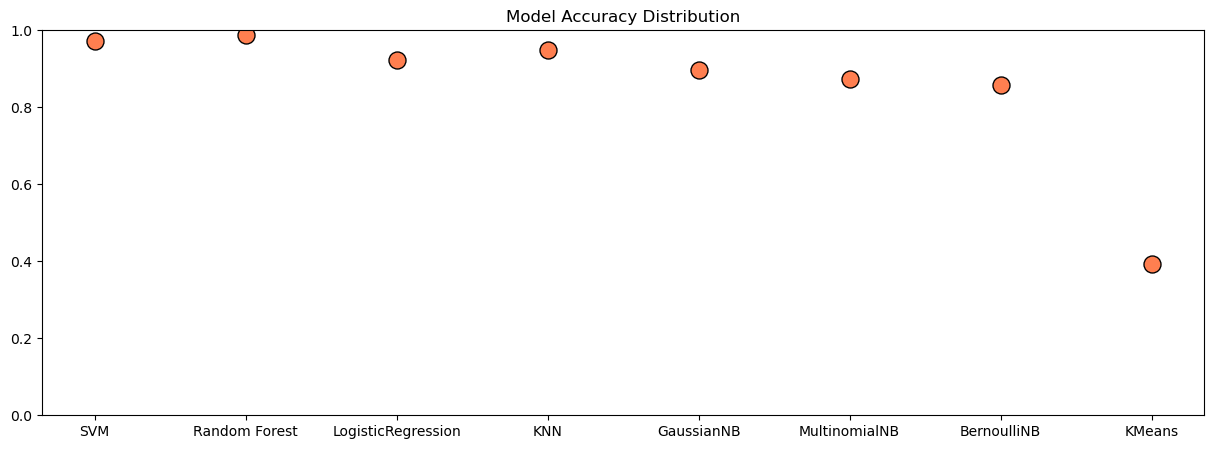

In [73]:
plt.figure(figsize=(15,5))
sns.scatterplot(x=models, y=accuracies, s=150, color='coral', edgecolor='black')
plt.ylim(0,1)
plt.title('Model Accuracy Distribution')
plt.show()

## Pie Chart

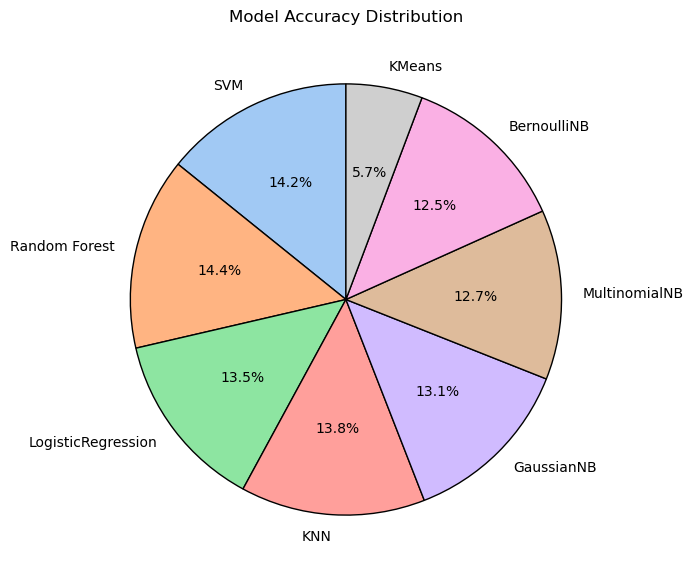

In [74]:
plt.figure(figsize=(7,7))
plt.pie(accuracies, labels=models, autopct='%1.1f%%', startangle=90, 
        colors=sns.color_palette("pastel"), wedgeprops={'edgecolor':'black'})
plt.title('Model Accuracy Distribution')
plt.show()

## Heatmap

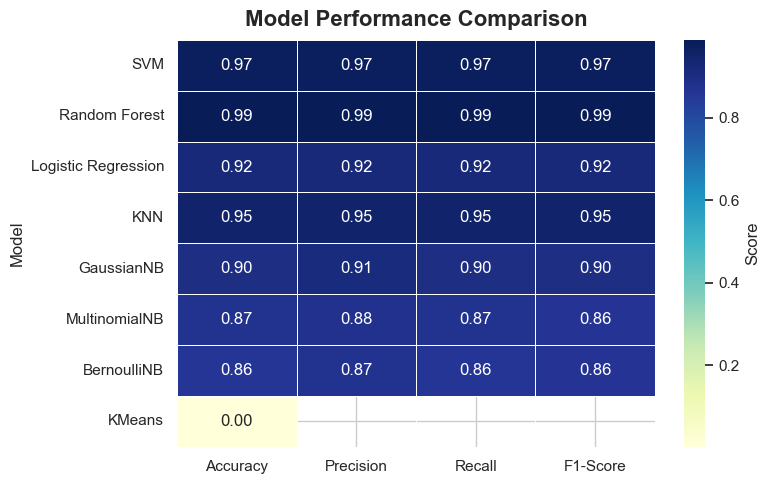

In [75]:
models = ['SVM', 'Random Forest', 'Logistic Regression', 'KNN', 
          'GaussianNB', 'MultinomialNB', 'BernoulliNB', 'KMeans']

predictions = [y_pred_svm, y_pred_rf, y_pred_lr, y_pred_knn, 
               y_pred_gnbs, y_pred_mnbs, y_pred_bnbs, y_pred_km]

accuracies, precisions, recalls, f1_scores = [], [], [], []

# KMeans unsupervised learning ka part hai to fir uski sirf accuracy find hogi but for heatmap all 4 things are required 
# to fir kmeans ko skip karne ke liye loop run kara hai

for model, y_pred in zip(models, predictions):
    if model == 'KMeans':
        acc = adjusted_rand_score(y_test, y_pred)
        accuracies.append(acc)
        precisions.append(np.nan)
        recalls.append(np.nan)
        f1_scores.append(np.nan)
    else:
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

df_metrics = pd.DataFrame({
    'Model': models,
    'Accuracy': np.ravel(accuracies),
    'Precision': np.ravel(precisions),
    'Recall': np.ravel(recalls),
    'F1-Score': np.ravel(f1_scores)
}).set_index('Model')


sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.heatmap(df_metrics, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Score'}, mask=df_metrics.isnull())
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=10)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Confusion Matrix

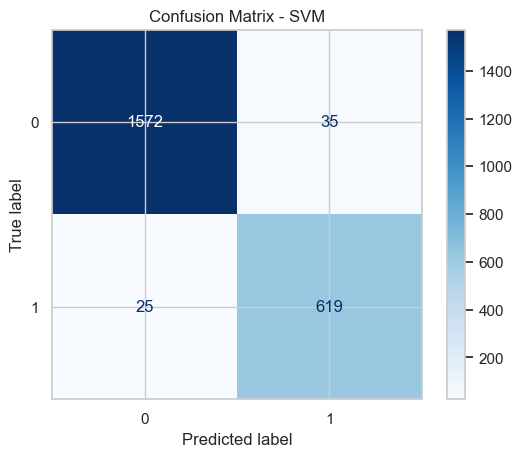

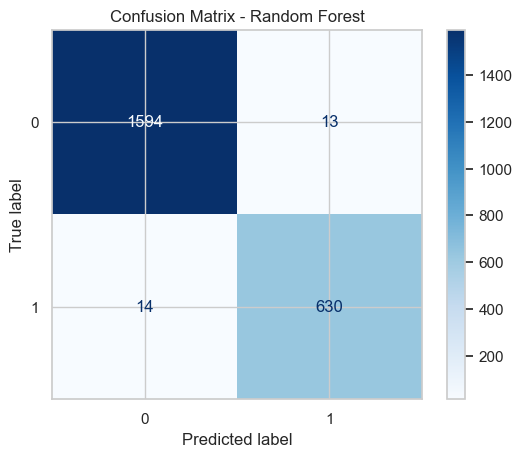

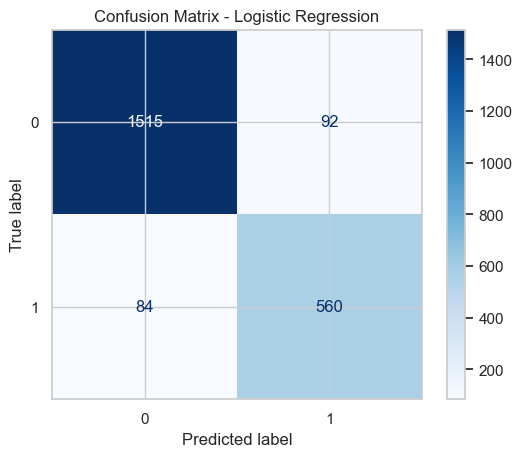

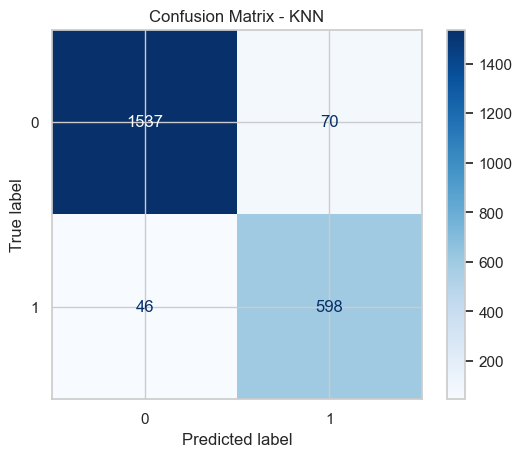

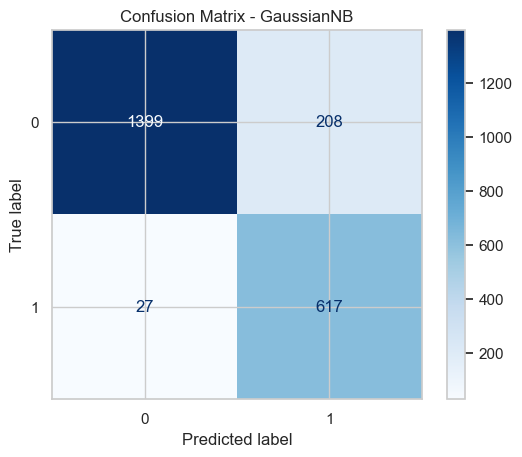

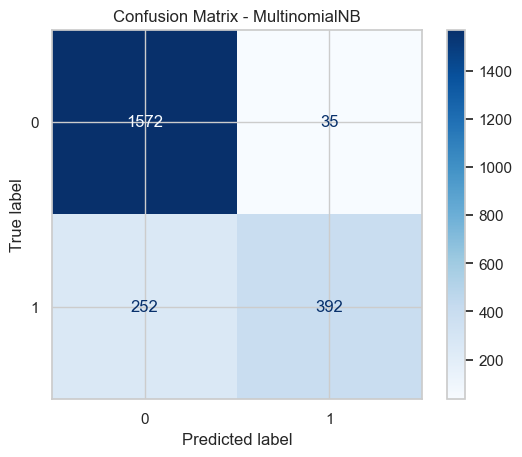

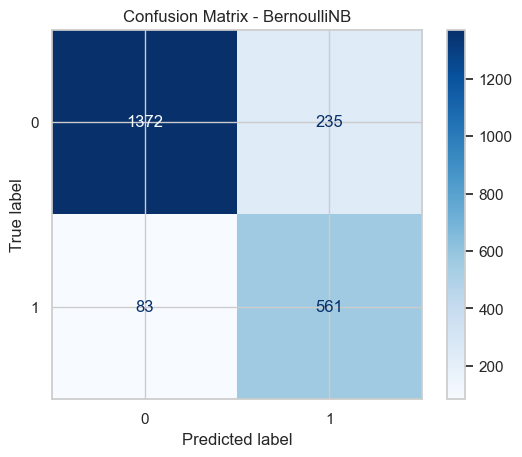

In [77]:
for model, y_pred in zip(models, predictions):
    if model != 'KMeans':
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues', values_format='d')
        plt.title(f'Confusion Matrix - {model}')
        plt.show()

In [79]:
cm

array([[1372,  235],
       [  83,  561]])

In [84]:
def plot_decision_boundary_auto(model, X, y, title="Decision Boundary"):
    if isinstance(X, pd.DataFrame):
        feature_names = X.columns
        X_np = X.values
    else:
        feature_names = [f"Feature {i}" for i in range(X.shape[1])]
        X_np = X

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        top2_idx = np.argsort(importances)[-2:]  # top 2 indices
        top_features = [feature_names[i] for i in top2_idx]
        X_2d = X_np[:, top2_idx]
    else:
        X_2d = X_np[:, :2]
        top_features = feature_names[:2]

    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    try:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    except Exception as e:
        from sklearn.base import clone
        model_2d = clone(model)
        model_2d.fit(X_2d, y)
        Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)

    # Color maps
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    plt.figure(figsize=(9,7))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=y, 
                    palette=cmap_bold.colors[:len(np.unique(y))], 
                    edgecolor='k', s=60)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(top_features[0])
    plt.ylabel(top_features[1])
    plt.tight_layout()
    plt.show()

## SVM decision boundary

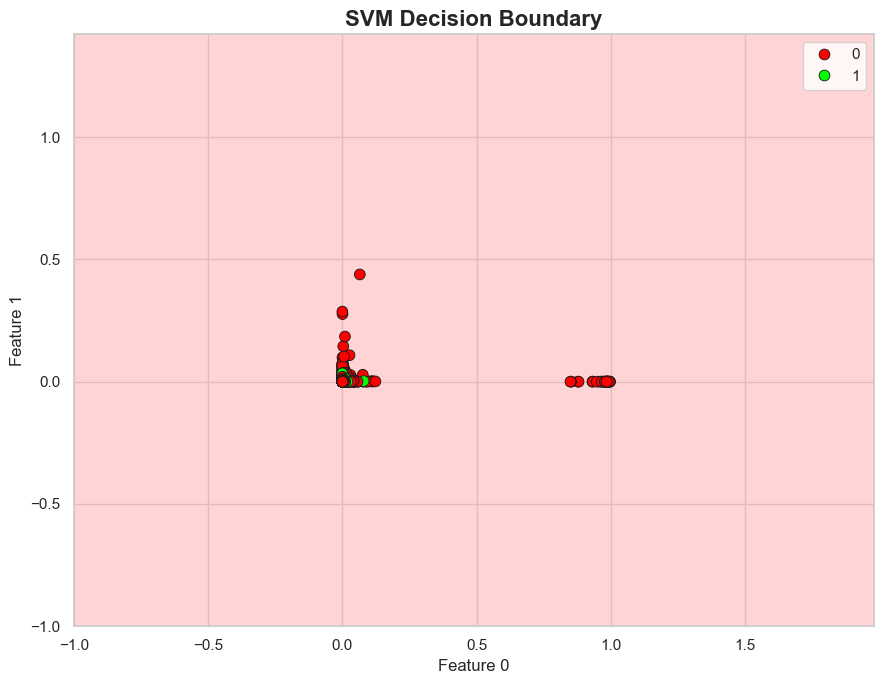

In [85]:
plot_decision_boundary_auto(svm, X_test, y_test, title="SVM Decision Boundary")

## Random Forest decision boundary

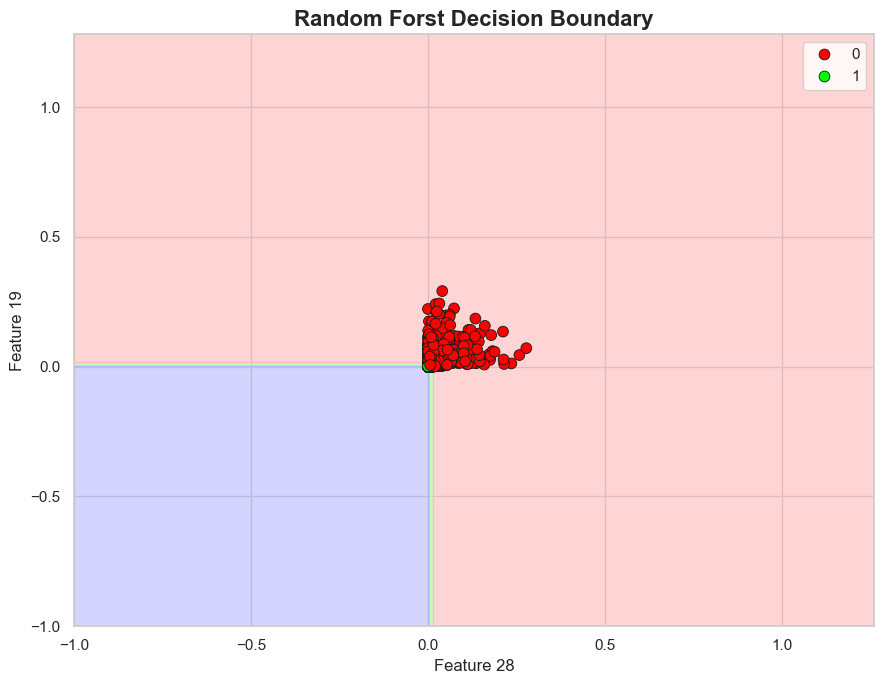

In [87]:
plot_decision_boundary_auto(rf, X_test, y_test, title="Random Forst Decision Boundary")

## Logistic Regression decision boundary

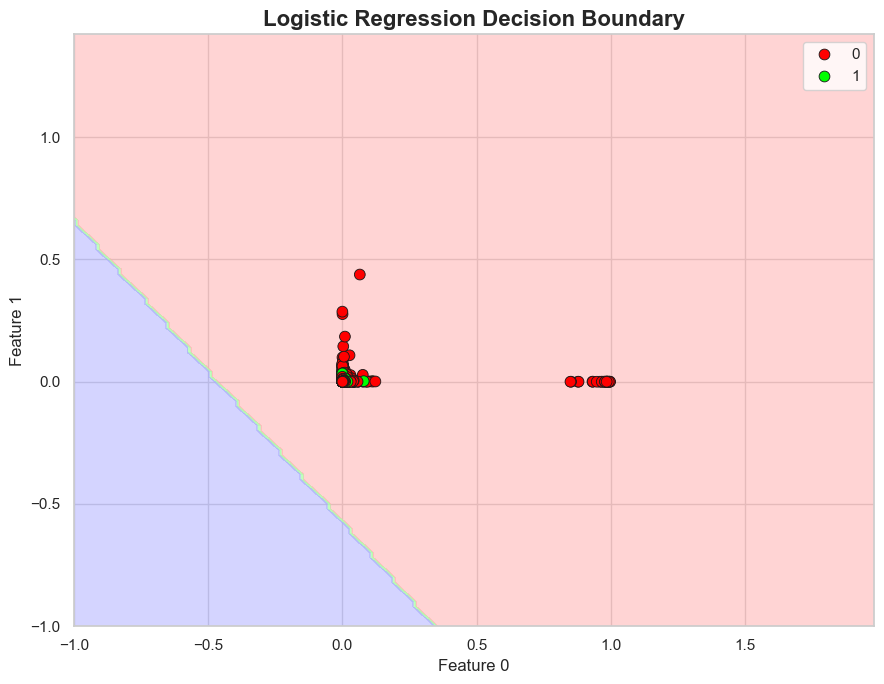

In [88]:
plot_decision_boundary_auto(lr, X_test, y_test, title="Logistic Regression Decision Boundary")

## KNN decision boundary

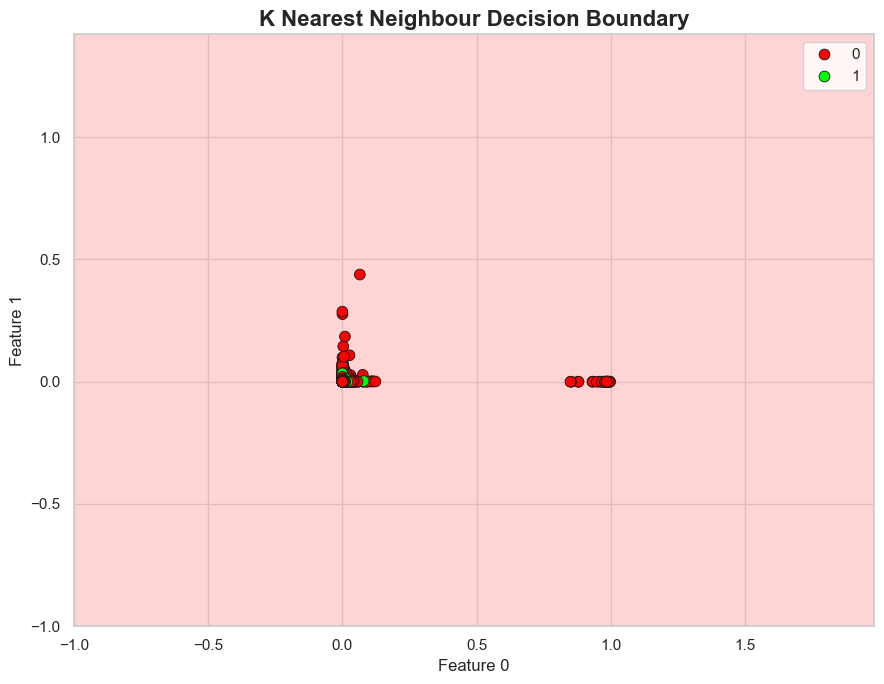

In [89]:
plot_decision_boundary_auto(knn, X_test, y_test, title="K Nearest Neighbour Decision Boundary")

In [92]:
print("=== SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print("=== KNN Classification Report ===")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

print("=== Gaussian Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_gnbs, target_names=le.classes_))

print("=== Multinomial Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_mnbs, target_names=le.classes_))

print("=== Bernoulli Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_bnbs, target_names=le.classes_))

print("=== KMeans Clustering Evaluation ===")
print("Adjusted Rand Index:", adjusted_rand_score(y_test, y_pred_km))

=== SVM Classification Report ===
              precision    recall  f1-score   support

    diseased       0.98      0.98      0.98      1607
     healthy       0.95      0.96      0.95       644

    accuracy                           0.97      2251
   macro avg       0.97      0.97      0.97      2251
weighted avg       0.97      0.97      0.97      2251

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

    diseased       0.99      0.99      0.99      1607
     healthy       0.98      0.98      0.98       644

    accuracy                           0.99      2251
   macro avg       0.99      0.99      0.99      2251
weighted avg       0.99      0.99      0.99      2251

=== KNN Classification Report ===
              precision    recall  f1-score   support

    diseased       0.97      0.96      0.96      1607
     healthy       0.90      0.93      0.91       644

    accuracy                           0.95      2251
   macro avg    

In [93]:
import joblib

best_model = svm  
joblib.dump(best_model, "plant_disease_traditional_model.pkl")

print("Model saved successfully!")


Model saved successfully!


In [94]:
def extract_features_from_frame(img):
    img = cv2.resize(img, (128, 128))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [95]:
model = joblib.load("plant_disease_traditional_model.pkl")

le = joblib.load("label_encoder.pkl")
labels = le.classes_


In [15]:
cam = cv2.VideoCapture(1) 
cv2.namedWindow("Leaf Disease Detection - Traditional ML")

while True:
    ret, frame = cam.read()
    if not ret:
        print("Failed to grab frame")
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        leaf = frame[y:y+h, x:x+w]

        if leaf.size > 0:
            features = extract_features_from_frame(leaf).reshape(1, -1)
            prediction = model.predict(features)[0]
            label = labels[int(prediction)]

            
            if hasattr(model, "predict_proba"):
                proba = model.predict_proba(features)[0]
                confidence = np.max(proba) * 100
            else:
                confidence = 0  

            
            text = f"{label} ({confidence:.1f}%)" if confidence > 0 else label
            color = (0, 255, 0) if label == 'healthy' else (0, 0, 255)

            cv2.putText(frame, text, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)

    cv2.imshow("Leaf Disease Detection - Traditional ML", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cam.release()
cv2.destroyAllWindows()
